# Calling subagents in a graph

In this lab, you'll build a customer support system using LangGraph's multi-agent architecture. The system uses a **supervisor agent** that delegates tasks to specialized **subagents** (music catalog and invoice information).

## Setup
Before running the cells in this notebook, start Studio locally

In [1]:
from langchain.messages import ToolMessage, SystemMessage, HumanMessage
from langgraph.checkpoint.memory import MemorySaver
from langgraph.store.memory import InMemoryStore
from dotenv import load_dotenv
from langchain.chat_models import init_chat_model

load_dotenv(dotenv_path="../.env", override=True)
model = init_chat_model("anthropic:claude-haiku-4-5")
# Initializing long term memory store 
in_memory_store = InMemoryStore()
# Initializing checkpoint for thread-level memory 
checkpointer = MemorySaver()

In [2]:
from typing_extensions import TypedDict
from typing import Annotated, List
from langgraph.graph.message import AnyMessage, add_messages
from langgraph.managed.is_last_step import RemainingSteps

class InputState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

class State(InputState):
    customer_id: int
    loaded_memory: str
    remaining_steps: int

In [3]:
supervisor_prompt = """
<background>
You are an expert customer support assistant for a digital music store. You can handle music catalog or invoice related question regarding past purchases, song or album availabilities. 
You are dedicated to providing exceptional service and ensuring customer queries are answered thoroughly, and have a team of subagents that you can use to help answer queries from customers. 
Your primary role is to delegate tasks to this multi-agent team in order to answer queries from customers. 
</background>

<important_instructions>
Always respond to the customer through summarizing the findings of the individual responses from subagents. 
If a question is unrelated to music or invoice, politely remind the customer regarding your scope of work. Do not answer unrelated answers.
Based on the existing steps that have been taken in the messages, your role is to call the appropriate subagent based on the users query.
</important_instructions>

<tools>
You have 2 tools available to delegate to the subagents on your team:
1. music_catalog_information_subagent: Call this tool to delegate to the music subagent. The music agent has access to user's saved music preferences. It can also retrieve information about the digital music store's music 
catalog (albums, tracks, songs, etc.) from the database. 
2. invoice_information_subagent: Call this tool to delegate to the invoice subagent. This subagent is able to retrieve information about a customer's past purchases or invoices 
from the database. 
</tools>
"""


## Connect to Remote Subagents

Using `RemoteGraph`, we connect to subagents running on a LangGraph server

In [4]:
from langgraph_sdk import get_client, get_sync_client
from langgraph.pregel.remote import RemoteGraph

url = "http://localhost:2024"
# client = get_client(url=url)
# sync_client = get_sync_client(url=url)

music_catalog_subagent = RemoteGraph(
    "Music Catalog Subagent", 
    url = "http://localhost:2024", 
    distributed_tracing=True  
)

invoice_information_subagent = RemoteGraph(
    "Invoice Subagent", 
    url = "http://localhost:2024",
    distributed_tracing=True
)

In [5]:
# from langchain_core.tools import tool
from langchain.tools import tool, ToolRuntime


@tool(
    name_or_callable="invoice_information_subagent",
    description="""
        An agent that can assistant with all invoice-related queries. It can retrieve information about a customers past purchases or invoices.
        """
)
def call_invoice_information_subagent(runtime: ToolRuntime, query: str):
    # Distributed tracing is enabled on the RemoteGraph, so traces will be nested automatically
    result = invoice_information_subagent.invoke({
        "messages": [HumanMessage(content=query)],
        "customer_id": runtime.state.get("customer_id", {})
    })
    subagent_response = result["messages"][-1]["content"]
    return subagent_response


@tool(
    name_or_callable="music_catalog_subagent",
    description="""
        An agent that can assistant with all music-related queries. This agent has access to user's saved music preferences. It can also retrieve information about the digital music store's music 
        catalog (albums, tracks, songs, etc.) from the database. 
        """
)
def call_music_catalog_subagent(query: str):
    # Distributed tracing is enabled on the RemoteGraph, so traces will be nested automatically
    result = music_catalog_subagent.invoke({
        "messages": [HumanMessage(content=query)]
    })
    subagent_response = result["messages"][-1]["content"]
    return subagent_response


## Create the Supervisor Agent

The `create_agent` function assembles the supervisor with its tools, prompt, state schema, and memory components.

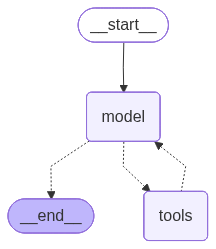

In [6]:
from langchain.agents import create_agent

supervisor = create_agent(
    model=model, 
    tools=[call_invoice_information_subagent, call_music_catalog_subagent], 
    name="supervisor",
    system_prompt=supervisor_prompt, 
    state_schema=State, 
    checkpointer=checkpointer, 
    store=in_memory_store
)
supervisor

## Test the Supervisor

Run a sample query to see the supervisor in action. All of the sub agent steps are visible in the trace. View the trace in Langsmith.

In [ ]:
from langsmith import uuid7

question = "my favorite songs are by the rolling stones, what albums do you have by the rolling stones?"
# question = "I am trying to find the invoice number for my most recent song purchase. Could you help me with it?"
config = {"configurable": {"thread_id": uuid7()}}

result = supervisor.invoke({"messages": [HumanMessage(content=question)], "customer_id": 32}, config=config)


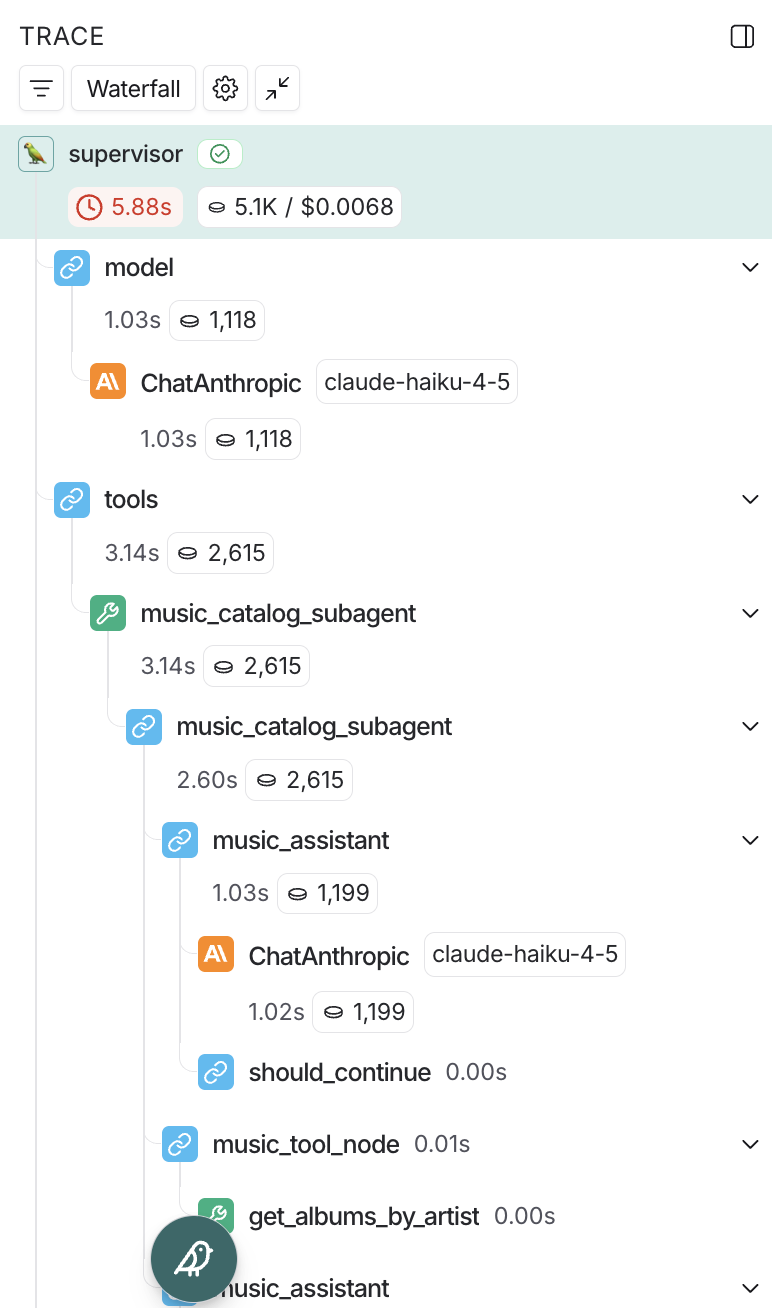

---

# Evaluation Strategy

Now we'll evaluate the system at multiple levels.

## Part 1: Test Routing Accuracy of the Supervisor

This evaluation checks whether the supervisor correctly routes queries to the appropriate subagent based on query content.

In [8]:

from langsmith import Client

ls_client = Client()

examples = [
    {
        "messages": "My customer ID is 1. What's my most recent purchase?", 
        "route": 'invoice_information_subagent'
    },
    {
        "messages": "What songs do you have by U2?", 
        "route": 'music_catalog_subagent'
    },
    {
        "messages": "My name is Aaron Mitchell. My number associated with my account is +1 (204) 452-6452. I am trying to find the invoice number for my most recent song purchase. Could you help me with it?", 
        "route": 'invoice_information_subagent'
    },
    {
        "messages": "Who recorded Wish You Were Here again? What other albums by them do you have?", 
        "route": 'music_catalog_subagent'
    }
]


dataset_name = "test-route-multi-agent-sdk"
if not ls_client.has_dataset(dataset_name=dataset_name):
    dataset = ls_client.create_dataset(dataset_name=dataset_name)
    ls_client.create_examples(
        inputs = [{"messages": ex["messages"]} for ex in examples],
        outputs = [{"route": ex["route"]} for ex in examples],
        dataset_id=dataset.id
    )

In [9]:
# async def run_supervisor_routing(inputs: dict):
#     config = {"configurable": {"thread_id": uuid7()}}
#     # result = supervisor.invoke({"messages": [HumanMessage(content=question)], "customer_id": 32}, config=config)

#     result = await supervisor.ainvoke({"messages": [HumanMessage(content=inputs['messages'])], "customer_id": 32}, config=config)

#     return {"route": result["messages"][2].name}

def run_supervisor_routing(inputs: dict):
    config = {"configurable": {"thread_id": uuid7()}}

    result = supervisor.invoke({"messages": [HumanMessage(content=inputs['messages'])], "customer_id": 32}, config=config)

    return {"route": result["messages"][2].name}

In [10]:
def correct(outputs: dict, reference_outputs: dict) -> bool:
    """Check if the agent chose the correct route."""
    return outputs['route'] == reference_outputs["route"]

In [11]:
# from langsmith import aevaluate

ls_client = Client()

# experiment_results = await aevaluate(
#     run_supervisor_routing,
#     data=dataset_name,
#     evaluators=[correct],
#     experiment_prefix="agent-singlestep",
#     max_concurrency=5,
# )

experiment_results = ls_client.evaluate(
    run_supervisor_routing,
    data=dataset_name,
    evaluators=[correct],
    experiment_prefix="agent-singlestep",
    max_concurrency=5,
)

/Users/conradcorbett/code/langgraph/lg-sub-agent-sdk/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


View the evaluation results for experiment: 'agent-singlestep-bb806811' at:
https://smith.langchain.com/o/a46cf24f-f360-4aa2-8be7-4362186e5ff1/datasets/cbb270c6-1bdc-46ff-8a4d-79d1e952e2fa/compare?selectedSessions=37a5b3f9-204b-4afa-ad58-372a6fbf32fb




0it [00:00, ?it/s]/Users/conradcorbett/code/langgraph/lg-sub-agent-sdk/.venv/lib/python3.13/site-packages/pydantic/v1/main.py:1054: UserWarning: LangSmith now uses UUID v7 for run and trace identifiers. This warning appears when passing custom IDs. Please use: from langsmith import uuid7
            id = uuid7()
Future versions will require UUID v7.
  input_data = validator(cls_, input_data)
4it [00:08,  2.07s/it]


## Part 2: Evaluate Individual Subagent

Test the invoice subagent in isolation to ensure it correctly handles invoice-specific queries.

In [12]:
from openevals.llm import create_async_llm_as_judge
from openevals.prompts import CORRECTNESS_PROMPT

# Using Open Eval pre-built 
correctness_evaluator = create_async_llm_as_judge(
    prompt=CORRECTNESS_PROMPT,
    feedback_key="correctness",
    judge=model
)
# print(CORRECTNESS_PROMPT)

In [13]:
import json

# Load the dataset from JSONL file
dataset_file = "data/dataset_invoice_sub_agent.jsonl"
examples_data = []

with open(dataset_file, 'r') as f:
    for line in f:
        if line.strip():  # Skip empty lines
            examples_data.append(json.loads(line))

print(f"Loaded {len(examples_data)} examples from {dataset_file}")

# Create a new dataset in LangSmith
dataset_name = "test-invoice-subagent-dataset"
    
# Check if dataset already exists
if ls_client.has_dataset(dataset_name=dataset_name):
    print(f"Dataset '{dataset_name}' already exists. Deleting and recreating...")
    # Get the dataset and delete it
    existing_dataset = ls_client.read_dataset(dataset_name=dataset_name)
    ls_client.delete_dataset(dataset_id=existing_dataset.id)

# Create the dataset
dataset = ls_client.create_dataset(
    dataset_name=dataset_name,
    description="Invoice subagent evaluation dataset with customer queries and expected responses"
)

# Upload examples to the dataset
ls_client.create_examples(
    inputs=[ex["inputs"] for ex in examples_data],
    outputs=[ex["outputs"] for ex in examples_data],
    dataset_id=dataset.id
)

print(f"✓ Created dataset '{dataset_name}' with {len(examples_data)} examples")
print(f"Dataset ID: {dataset.id}")

Loaded 2 examples from data/dataset_invoice_sub_agent.jsonl
✓ Created dataset 'test-invoice-subagent-dataset' with 2 examples
Dataset ID: a0b3a671-2751-40f0-a9ff-7653b4b014fb


In [14]:
client = Client()
invoice_information_subagent_client = get_client(url="http://localhost:2024")

# Async wrapper using the same logic as call_music_catalog_subagent
async def run_invoice_information_subagent(inputs: dict):
    """Async wrapper that reuses the call_music_catalog_subagent logic."""
    query = inputs.get("query", "")
    customer_id = inputs.get("customer_id", 1)
    inpts = {
        "messages": [HumanMessage(content=query)],
        "customer_id": customer_id
    }
    thread = await invoice_information_subagent_client.threads.create()

    result = await invoice_information_subagent_client.runs.wait(
        thread["thread_id"], 
        # {
        # "messages": [HumanMessage(content=query)],
        # "customer_id": customer_id
        # },
        "Invoice Subagent",
        input=inpts,
        )
    
    subagent_response = result["messages"][-1]["content"]
    
    return {
        "content": subagent_response
    }


In [15]:
from langsmith import aevaluate

# Run the evaluation
experiment_results = await aevaluate(
    run_invoice_information_subagent,
    data="test-invoice-subagent-dataset",
    evaluators=[correctness_evaluator],
    experiment_prefix="music-catalog-e2e",
    num_repetitions=1,
    max_concurrency=2
)

View the evaluation results for experiment: 'music-catalog-e2e-856acedd' at:
https://smith.langchain.com/o/a46cf24f-f360-4aa2-8be7-4362186e5ff1/datasets/a0b3a671-2751-40f0-a9ff-7653b4b014fb/compare?selectedSessions=782f31ba-a242-4a98-abb7-d9a7f6991cb0




2it [00:07,  3.77s/it]


## Part 3: e2e test for input/output to supervisor

Test the supervisors reponse

In [16]:
import json

# Load the dataset from JSONL file
dataset_file = "data/dataset_e2e_supervisor.jsonl"
examples_data = []

with open(dataset_file, 'r') as f:
    for line in f:
        if line.strip():  # Skip empty lines
            examples_data.append(json.loads(line))

print(f"Loaded {len(examples_data)} examples from {dataset_file}")

# Create a new dataset in LangSmith
dataset_name = "test-e2e-supervisor-dataset"

# Check if dataset already exists
if ls_client.has_dataset(dataset_name=dataset_name):
    print(f"Dataset '{dataset_name}' already exists. Deleting and recreating...")
    # Get the dataset and delete it
    existing_dataset = ls_client.read_dataset(dataset_name=dataset_name)
    ls_client.delete_dataset(dataset_id=existing_dataset.id)

# Create the dataset
dataset = ls_client.create_dataset(
    dataset_name=dataset_name,
    description="Invoice subagent evaluation dataset with customer queries and expected responses"
)

# Upload examples to the dataset
ls_client.create_examples(
    inputs=[ex["inputs"] for ex in examples_data],
    outputs=[ex["outputs"] for ex in examples_data],
    dataset_id=dataset.id
)

print(f"✓ Created dataset '{dataset_name}' with {len(examples_data)} examples")
print(f"Dataset ID: {dataset.id}")

Loaded 3 examples from data/dataset_e2e_supervisor.jsonl
✓ Created dataset 'test-e2e-supervisor-dataset' with 3 examples
Dataset ID: 9fb7aa04-ef48-4efd-85d4-a882dfa6274c


In [17]:
async def run_supervisor_e2e(inputs: dict):
    query = inputs.get("messages", [None])[0].get("content", "")
    customer_id = inputs.get("customer_id", 1)

    result = await supervisor.ainvoke(
        {"messages": [HumanMessage(content=query)], "customer_id": customer_id},
        config={"thread_id": uuid7()}
    )
    return {"content": result["messages"][-1].content}

In [18]:
# Run the evaluation
experiment_results = await ls_client.aevaluate(
    run_supervisor_e2e,
    data="test-e2e-supervisor-dataset",
    evaluators=[correctness_evaluator],
    experiment_prefix="e2e",
    num_repetitions=1,
    max_concurrency=2
)

View the evaluation results for experiment: 'e2e-6886c6c0' at:
https://smith.langchain.com/o/a46cf24f-f360-4aa2-8be7-4362186e5ff1/datasets/9fb7aa04-ef48-4efd-85d4-a882dfa6274c/compare?selectedSessions=90114669-c9e2-43c2-b764-1e0b447eca6d




3it [00:18,  6.02s/it]
